In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from scipy.optimize import minimize

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [4]:
# ==========================================
# Research Configuration
# ==========================================

TICKERS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "NVDA",
    "META",
    "TSLA"
]

MARKET_TICKER = "SPY"

START_DATE = "2021-01-01"
END_DATE = "2026-01-01"

# Annual risk-free rate
RISK_FREE_RATE = 0.04

# Maximum portfolio weight for each stock
MAX_WEIGHT = 0.2

# Trading cost assumption
TRANSACTION_COST = 0.001  # 10 bps = 0.10%

# Trading / return convention
TRADING_DAYS = 252

# Shrinkage parameter
SHRINKAGE_LAMBDA = 0.50

print("Assets:", TICKERS)
print("Market proxy:", MARKET_TICKER)
print("Period:", START_DATE, "to", END_DATE)
print("Risk-free rate:", RISK_FREE_RATE)
print("Maximum weight:", MAX_WEIGHT)

Assets: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA']
Market proxy: SPY
Period: 2021-01-01 to 2026-01-01
Risk-free rate: 0.04
Maximum weight: 0.2


In [8]:
# =========================
# Download Historical Data
# =========================

import yfinance as yf

all_tickers = TICKERS + [MARKET_TICKER]

print("Downloading:")
print(all_tickers)
print(f"Start: {START_DATE}")
print(f"End:   {END_DATE}")

raw_data = yf.download(
    tickers=all_tickers,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    progress=True,
    group_by="column",
    threads=True
)

print("\nDownload completed.")
print("Shape:", raw_data.shape)

print("\nFirst 10 rows:")
display(raw_data.head(10))

print("\nLast 10 rows:")
display(raw_data.tail(10))

print("\nDate range:")
print("First date:", raw_data.index.min())
print("Last date: ", raw_data.index.max())

[*********************100%***********************]  8 of 8 completed

Downloading:
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'SPY']
Start: 2021-01-01
End:   2026-01-01

Download completed.
Shape: (1255, 40)

First 10 rows:


Price         Close                                                                  High                            \
Ticker         AAPL     AMZN   GOOGL     META     MSFT    NVDA      SPY     TSLA     AAPL     AMZN   GOOGL     META   
Date                                                                                                                  
2021-01-04 125.6325 159.3315 85.4930 266.5988 207.5654 13.0462 341.5887 243.2567 129.7099 163.6000 87.2938 272.6061   
2021-01-05 127.1858 160.9255 86.1824 268.6111 207.7656 13.3360 343.9413 245.0367 127.8945 161.1690 86.5182 270.0287   
2021-01-06 122.9045 156.9190 85.3320 261.0179 202.3784 12.5498 345.9976 251.9933 127.2246 159.8755 86.3766 265.4192   
2021-01-07 127.0984 158.1080 87.8808 266.4006 208.1374 13.2755 351.1383 272.0133 127.7877 160.4270 88.0531 269.2456   
2021-01-08 128.1954 159.1350 89.0442 265.2408 209.4056 13.2086 353.1390 293.3400 128.7585 159.5320 89.1200 266.6088   
2021-01-11 125.2150 155.7105 86.9868 254.6042 207.3747 13.5516 350.7585 270.3967 126.3703 157.8190 88.3780 261.1764   
2021-01-12 125.0403 156.0415 86.0526 248.9043 204.9337 13.4155 350.8325 283.1467 125.9043 157.1070 87.5618 257.4591   
2021-01-13 127.0693 158.2945 86.5390 249.4494 206.2782 13.4623 351.7773 284.8033 127.6129 159.4975 86.9917 251.7393   
2021-01-14 125.1471 156.3735 85.7302 243.5017 203.1126 13.1325 350.5455 281.6667 127.1761 158.9000 87.5445 252.8100   
2021-01-15 123.4288 155.2125 85.5668 249.1719 202.7598 12.7935 347.9891 275.3867 126.4189 157.1275 86.5573 251.6501   

Price                                              Low                                                               \
Ticker         MSFT    NVDA      SPY     TSLA     AAPL     AMZN   GOOGL     META     MSFT    NVDA      SPY     TSLA   
Date                                                                                                                  
2021-01-04 212.6284 13.5824 347.7574 248.1633 123.0598 157.2010 84.5524 262.8914 204.8193 12.8960 337.9115 239.0633   
2021-01-05 208.3568 13.3745 345.0251 246.9467 124.6811 158.2530 85.0358 265.8752 205.6679 13.0198 340.9033 239.7333   
2021-01-06 206.4212 13.1770 349.1746 258.0000 122.6909 156.5580 84.0056 257.7466 202.0828 12.5214 341.8943 249.7000   
2021-01-07 209.1386 13.3091 351.8793 272.3300 124.1278 157.7500 85.5242 262.4751 203.7704 12.8204 348.1836 258.4000   
2021-01-08 210.3210 13.3521 353.3520 294.8300 126.4286 157.1100 87.2309 260.8890 206.9361 12.9751 349.2858 279.4633   
2021-01-11 208.7286 13.8893 352.5091 284.8100 124.7491 155.5000 86.7812 253.6723 206.6500 13.2939 349.8600 267.8733   
2021-01-12 207.0028 13.6839 351.8421 289.3333 123.1569 154.3000 85.0101 248.1211 203.3986 13.2765 348.6002 275.7800   
2021-01-13 206.6786 13.5551 352.7684 286.8233 124.7394 156.1040 85.5519 247.0307 203.9803 13.3163 349.9804 277.3333   
2021-01-14 207.3461 13.5299 353.0186 287.6667 125.0015 156.0295 85.4900 242.4807 202.8456 13.1129 350.2121 279.5833   
2021-01-15 204.5333 13.2569 349.7304 286.6333 123.2929 154.7585 84.7788 245.0085 202.1687 12.7826 346.1366 273.0333   

Price          Open                                                                  Volume                      \
Ticker         AAPL     AMZN   GOOGL     META     MSFT    NVDA      SPY     TSLA       AAPL      AMZN     GOOGL   
Date                                                                                                              
2021-01-04 129.6225 163.5000 87.1705 272.3880 212.1803 13.0370 347.6277 239.8200  143301900  88228000  37324000   
2021-01-05 125.1277 158.3005 85.4415 265.9545 207.1554 13.0325 340.9496 241.2200   97664900  53110000  20360000   
2021-01-06 123.9918 157.3240 84.2117 259.7193 202.3021 13.1546 342.4408 252.8300  155088000  87896000  46588000   
2021-01-07 124.6132 157.8500 85.5242 263.5853 204.0851 12.9009 348.3595 259.2100  109578200  70290000  41936000   
2021-01-08 128.5643 159.0000 88.0204 265.9744 208.5093 13.2939 352.5184 285.3333  105158200  707540


Last 10 rows:


Price         Close                                                                    High                    \
Ticker         AAPL     AMZN    GOOGL     META     MSFT     NVDA      SPY     TSLA     AAPL     AMZN    GOOGL   
Date                                                                                                            
2025-12-17 271.1021 221.2700 296.1439 648.3435 473.1184 170.5409 664.2338 467.2600 275.4103 225.1900 307.4918   
2025-12-18 271.4511 226.7600 301.8728 663.2669 480.9289 173.7335 669.2497 483.3700 272.8872 229.2300 303.3699   
2025-12-19 272.9271 227.3500 306.5637 657.5970 482.8567 180.5675 675.3154 481.2000 273.8546 229.1300 306.6535   
2025-12-22 270.2344 228.4300 309.1786 660.3221 481.8630 183.2612 679.5225 488.7300 273.1365 229.4800 309.5279   
2025-12-23 271.6207 232.1400 313.7397 663.7560 483.7808 188.7683 682.6282 485.5600 271.7603 232.4500 314.3285   
2025-12-24 273.0667 232.3800 313.4802 666.3614 484.9434 188.1697 685.0295 485.4000 274.6823 232.9500 314.4683   
2025-12-26 272.6578 232.5200 312.9013 662.1089 484.6354 190.0852 684.9600 475.1900 274.6225 232.9900 314.4783   
2025-12-29 273.0169 232.0700 312.9512 657.5172 484.0292 187.7806 682.5190 459.6400 273.6152 232.6000 313.4103   
2025-12-30 272.3387 232.5300 313.2407 664.7642 484.4069 187.1022 681.6855 454.4300 273.3360 232.7700 316.3346   
2025-12-31 271.1220 230.8200 312.3923 658.9147 480.5711 186.0646 676.6350 449.7200 272.9371 232.9900 313.9693   

Price                                                        Low                                               \
Ticker         META     MSFT     NVDA      SPY     TSLA     AAPL     AMZN    GOOGL     META     MSFT     NVDA   
Date                                                                                                            
2025-12-17 660.0526 476.9740 175.7188 673.1773 495.2800 270.9026 220.9900 295.5451 648.0441 472.0055 169.9124   
2025-12-18 669.3660 486.5135 175.7388 673.4741 490.8600 266.2254 224.4100 298.6491 655.2911 474.8773 171.4189   
2025-12-19 669.8052 484.7745 181.0264 675.8115 490.4900 269.1673 225.5800 300.3857 657.0080 479.4483 175.9283   
2025-12-22 672.3806 485.6490 183.7301 680.0483 498.8300 269.7757 226.7100 304.7072 655.4807 479.6470 181.9243   
2025-12-23 664.8141 484.7546 188.8880 682.8664 491.9700 268.8283 228.7300 308.7195 657.0779 481.6841 182.4730   
2025-12-24 666.9903 486.0762 188.4690 685.4760 490.9000 271.4611 231.3300 311.3144 661.0209 481.7735 186.1544   
2025-12-26 667.7588 485.0428 192.2402 686.2995 489.0900 272.1193 231.1800 311.6737 660.1424 482.8964 187.5611   
2025-12-29 659.0744 485.2714 188.3193 683.8586 469.4000 271.6107 230.7700 310.0169 653.2248 481.1276 185.4760   
2025-12-30 671.0230 486.5930 188.5488 683.2235 463.1200 271.5409 230.2000 311.8533 656.6687 482.4393 186.4936   
2025-12-31 663.8159 485.0627 190.1151 682.0329 456.5500 271.0123 230.1200 310.8354 658.2658 480.2531 186.0546   

Price                            Open                                                                    Volume  \
Ticker          SPY     TSLA     AAPL     AMZN    GOOGL     META     MSFT     NVDA      SPY     TSLA       AAPL   
Date                                                                                                              
2025-12-17 664.0359 466.2000 274.2635 224.6600 307.4120 654.4426 473.9035 175.6889 672.6331 488.2200   50138700   
2025-12-18 667.6965 473.1200 272.8673 225.7100 301.1342 655.8601 475.1754 174.1225 670.3676 478.1600   51630700   
2025-12-19 671.2272 474.7200 271.4112 226.7600 301.1442 665.2333 484.2876 176.2576 671.3464 488.1200  144632000   
2025-12-22 675.3153 485.3300 272.1193 228.6100 309.2784 660.4718 483.0554 183.4906 678.6393 489.8800   36571800   
2025-12-23 678.5699 482.8400 270.1048 229.0600 309.0288 658.8747 481.9226 182.5428 678.6195 489.4000   29642000   
2025-12-24 682.4695 476.8000 271.6007 232.1300 314.1589 661.3504 482.6181 187.5012 682.6183 488.4800   17910600   
2025-12-26 683.9280 473.8


Date range:
First date: 2021-01-04 00:00:00
Last date:  2025-12-31 00:00:00


In [9]:
# ==========================================
# Extract Close Prices
# ==========================================

if isinstance(prices_raw.columns, pd.MultiIndex):
    prices = prices_raw["Close"].copy()
else:
    prices = prices_raw.copy()

prices = prices[TICKERS + [MARKET_TICKER]]

prices.head()

Ticker,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,SPY
Date,,,,,,,,
2021-01-04,125.6325,207.5654,85.4930,159.3315,13.0462,266.5988,243.2567,341.5887
2021-01-05,127.1858,207.7656,86.1824,160.9255,13.3360,268.6111,245.0367,343.9413
2021-01-06,122.9045,202.3784,85.3320,156.9190,12.5498,261.0179,251.9933,345.9976
2021-01-07,127.0984,208.1374,87.8808,158.1080,13.2755,266.4006,272.0133,351.1383
2021-01-08,128.1954,209.4056,89.0442,159.1350,13.2086,265.2408,293.3400,353.1390


In [10]:
print("Shape:", prices.shape)
print("Columns:", prices.columns.tolist())

Shape: (1255, 8)
Columns: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'SPY']


In [11]:
# ==========================================
# Data Quality Check
# ==========================================

print("Missing values:")
print(prices.isna().sum())

print("\nNumber of observations:")
print(prices.count())

print("\nDate range:")
print(prices.index.min(), "to", prices.index.max())

Missing values:
Ticker
AAPL     0
MSFT     0
GOOGL    0
AMZN     0
NVDA     0
META     0
TSLA     0
SPY      0
dtype: int64

Number of observations:
Ticker
AAPL     1255
MSFT     1255
GOOGL    1255
AMZN     1255
NVDA     1255
META     1255
TSLA     1255
SPY      1255
dtype: int64

Date range:
2021-01-04 00:00:00 to 2025-12-31 00:00:00


In [12]:
missing_rows = prices[prices.isna().any(axis=1)]

print("Rows with missing values:", len(missing_rows))

missing_rows.head()

Rows with missing values: 0


Ticker,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,SPY
Date,,,,,,,,


In [13]:
prices = prices.dropna()

print("Cleaned data shape:", prices.shape)
print("Remaining missing values:")
print(prices.isna().sum())

Cleaned data shape: (1255, 8)
Remaining missing values:
Ticker
AAPL     0
MSFT     0
GOOGL    0
AMZN     0
NVDA     0
META     0
TSLA     0
SPY      0
dtype: int64


In [14]:
# ==========================================
# Daily Returns
# ==========================================

returns = prices.pct_change().dropna()

asset_returns = returns[TICKERS]
market_returns = returns[MARKET_TICKER]

returns.head()

Ticker,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,SPY
Date,,,,,,,,
2021-01-05,0.0124,0.0010,0.0081,0.0100,0.0222,0.0075,0.0073,0.0069
2021-01-06,-0.0337,-0.0259,-0.0099,-0.0249,-0.0590,-0.0283,0.0284,0.0060
2021-01-07,0.0341,0.0285,0.0299,0.0076,0.0578,0.0206,0.0794,0.0149
2021-01-08,0.0086,0.0061,0.0132,0.0065,-0.0050,-0.0044,0.0784,0.0057
2021-01-11,-0.0232,-0.0097,-0.0231,-0.0215,0.0260,-0.0401,-0.0782,-0.0067


In [15]:
# ==========================================
# Basic Return Statistics
# ==========================================

annualized_return = asset_returns.mean() * TRADING_DAYS
annualized_volatility = asset_returns.std() * np.sqrt(TRADING_DAYS)

basic_stats = pd.DataFrame({
    "Annualized Return": annualized_return,
    "Annualized Volatility": annualized_volatility
})

basic_stats

,Annualized Return,Annualized Volatility
Ticker,,
AAPL,0.1932,0.2786
MSFT,0.2017,0.2571
GOOGL,0.3089,0.3115
AMZN,0.1360,0.3511
NVDA,0.6695,0.5222
META,0.2772,0.4341
TSLA,0.3066,0.6074


In [16]:
# ==========================================
# Individual Asset Sharpe Ratio
# ==========================================

asset_sharpe = (
    annualized_return - RISK_FREE_RATE
) / annualized_volatility

basic_stats["Sharpe Ratio"] = asset_sharpe

basic_stats.sort_values(
    "Sharpe Ratio",
    ascending=False
)

,Annualized Return,Annualized Volatility,Sharpe Ratio
Ticker,,,
NVDA,0.6695,0.5222,1.2054
GOOGL,0.3089,0.3115,0.8635
MSFT,0.2017,0.2571,0.6289
AAPL,0.1932,0.2786,0.5499
META,0.2772,0.4341,0.5463
TSLA,0.3066,0.6074,0.4390
AMZN,0.1360,0.3511,0.2735


In [17]:
# ==========================================
# Maximum Drawdown
# ==========================================

def calculate_max_drawdown(price_series):
    running_max = price_series.cummax()
    drawdown = price_series / running_max - 1
    return drawdown.min()


max_drawdowns = asset_returns.copy()

asset_max_drawdown = {
    ticker: calculate_max_drawdown(prices[ticker])
    for ticker in TICKERS
}

basic_stats["Max Drawdown"] = pd.Series(asset_max_drawdown)

basic_stats.sort_values(
    "Max Drawdown",
    ascending=False
)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Ticker,,,,
AAPL,0.1932,0.2786,0.5499,-0.3336
MSFT,0.2017,0.2571,0.6289,-0.3715
GOOGL,0.3089,0.3115,0.8635,-0.4432
AMZN,0.1360,0.3511,0.2735,-0.5615
NVDA,0.6695,0.5222,1.2054,-0.6634
TSLA,0.3066,0.6074,0.4390,-0.7363
META,0.2772,0.4341,0.5463,-0.7674


In [18]:
# ==========================================
# Beta Calculation
# ==========================================

def calculate_beta(asset_return, market_return):
    covariance = np.cov(
        asset_return,
        market_return,
        ddof=1
    )[0, 1]

    market_variance = np.var(
        market_return,
        ddof=1
    )

    return covariance / market_variance


betas = {}

for ticker in TICKERS:
    betas[ticker] = calculate_beta(
        asset_returns[ticker],
        market_returns
    )

beta_series = pd.Series(betas, name="Beta")

beta_series

AAPL    1.2347
MSFT    1.1398
GOOGL   1.2520
AMZN    1.4678
NVDA    2.1332
META    1.5795
TSLA    2.0264
Name: Beta, dtype: float64

In [19]:
basic_stats["Beta"] = beta_series

basic_stats

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Beta
Ticker,,,,,
AAPL,0.1932,0.2786,0.5499,-0.3336,1.2347
MSFT,0.2017,0.2571,0.6289,-0.3715,1.1398
GOOGL,0.3089,0.3115,0.8635,-0.4432,1.2520
AMZN,0.1360,0.3511,0.2735,-0.5615,1.4678
NVDA,0.6695,0.5222,1.2054,-0.6634,2.1332
META,0.2772,0.4341,0.5463,-0.7674,1.5795
TSLA,0.3066,0.6074,0.4390,-0.7363,2.0264


In [21]:
# ==========================================
# Correlation Matrix
# ==========================================

correlation_matrix = asset_returns.corr()

correlation_matrix.round(3)

Ticker,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA
Ticker,,,,,,,
AAPL,1.0000,0.6340,0.5790,0.5610,0.5200,0.4890,0.5000
MSFT,0.6340,1.0000,0.6440,0.6550,0.6300,0.5920,0.4230
GOOGL,0.5790,0.6440,1.0000,0.6190,0.5280,0.5640,0.4160
AMZN,0.5610,0.6550,0.6190,1.0000,0.5570,0.6010,0.4490
NVDA,0.5200,0.6300,0.5280,0.5570,1.0000,0.4980,0.4680
META,0.4890,0.5920,0.5640,0.6010,0.4980,1.0000,0.3480
TSLA,0.5000,0.4230,0.4160,0.4490,0.4680,0.3480,1.0000


In [23]:
# ==========================================
# Annualized Covariance Matrix
# ==========================================

covariance_matrix = asset_returns.cov() * TRADING_DAYS

covariance_matrix.round(5)

Ticker,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA
Ticker,,,,,,,
AAPL,0.0776,0.0454,0.0502,0.0549,0.0756,0.0591,0.0847
MSFT,0.0454,0.0661,0.0516,0.0591,0.0847,0.0661,0.0661
GOOGL,0.0502,0.0516,0.0970,0.0677,0.0858,0.0762,0.0788
AMZN,0.0549,0.0591,0.0677,0.1232,0.1022,0.0916,0.0956
NVDA,0.0756,0.0847,0.0858,0.1022,0.2727,0.1130,0.1484
META,0.0591,0.0661,0.0762,0.0916,0.1130,0.1885,0.0917
TSLA,0.0847,0.0661,0.0788,0.0956,0.1484,0.0917,0.3689


In [24]:
# ==========================================
# Model 1: Historical Mean
# ==========================================

expected_return_historical = (
    asset_returns.mean() * TRADING_DAYS
)

expected_return_historical

Ticker
AAPL    0.1932
MSFT    0.2017
GOOGL   0.3089
AMZN    0.1360
NVDA    0.6695
META    0.2772
TSLA    0.3066
dtype: float64

In [25]:
# ==========================================
# Model 2: CAPM
# ==========================================

market_expected_return = (
    market_returns.mean() * TRADING_DAYS
)

capm_expected_returns = (
    RISK_FREE_RATE
    + beta_series
    * (market_expected_return - RISK_FREE_RATE)
)

print("Market expected return:", market_expected_return)

capm_expected_returns

Market expected return: 0.15199391308665236


AAPL    0.1783
MSFT    0.1677
GOOGL   0.1802
AMZN    0.2044
NVDA    0.2789
META    0.2169
TSLA    0.2669
Name: Beta, dtype: float64

In [26]:
# ==========================================
# Model 3: Shrinkage
# ==========================================

expected_return_shrinkage = (
    SHRINKAGE_LAMBDA
    * expected_return_historical
    +
    (1 - SHRINKAGE_LAMBDA)
    * capm_expected_returns
)

expected_return_shrinkage

Ticker
AAPL    0.1857
MSFT    0.1847
GOOGL   0.2446
AMZN    0.1702
NVDA    0.4742
META    0.2470
TSLA    0.2868
dtype: float64

In [27]:
# ==========================================
# Expected Return Comparison
# ==========================================

expected_return_comparison = pd.DataFrame({
    "Historical Mean": expected_return_historical,
    "CAPM": capm_expected_returns,
    "Shrinkage": expected_return_shrinkage
})

expected_return_comparison.round(4)

,Historical Mean,CAPM,Shrinkage
AAPL,0.1932,0.1783,0.1857
MSFT,0.2017,0.1677,0.1847
GOOGL,0.3089,0.1802,0.2446
AMZN,0.1360,0.2044,0.1702
NVDA,0.6695,0.2789,0.4742
META,0.2772,0.2169,0.2470
TSLA,0.3066,0.2669,0.2868


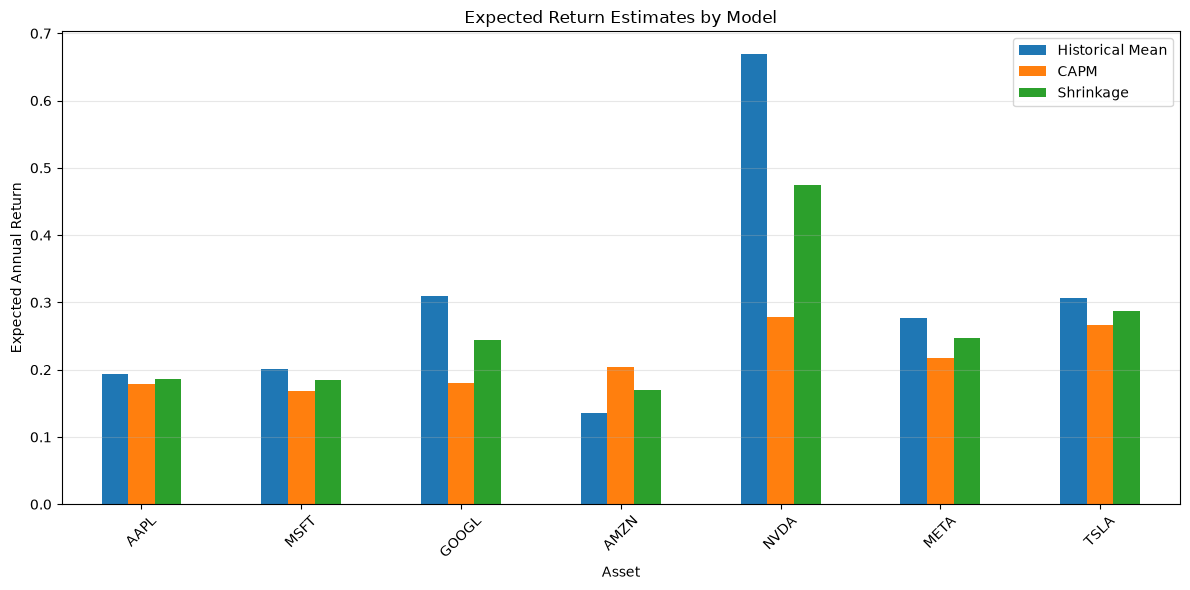

In [28]:
# ==========================================
# Expected Return Comparison Chart
# ==========================================

expected_return_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Expected Return Estimates by Model")
plt.ylabel("Expected Annual Return")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# ==========================================
# Portfolio Metrics
# ==========================================

def portfolio_return(weights, expected_returns):
    return np.dot(weights, expected_returns)


def portfolio_volatility(weights, covariance_matrix):
    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(covariance_matrix, weights)
        )
    )


def portfolio_sharpe(
    weights,
    expected_returns,
    covariance_matrix,
    risk_free_rate
):
    ret = portfolio_return(
        weights,
        expected_returns
    )

    vol = portfolio_volatility(
        weights,
        covariance_matrix
    )

    return (ret - risk_free_rate) / vol

In [30]:
# ==========================================
# Portfolio Constraints
# ==========================================

n_assets = len(TICKERS)

initial_weights = np.ones(n_assets) / n_assets

bounds = tuple(
    (0, MAX_WEIGHT)
    for _ in range(n_assets)
)

constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

initial_weights

array([0.14285714, 0.14285714, 0.14285714, 0.14285714, 0.14285714,
       0.14285714, 0.14285714])

In [31]:
# ==========================================
# Minimum Variance Portfolio
# ==========================================

def optimize_minimum_variance(
    covariance_matrix,
    max_weight=MAX_WEIGHT
):
    n = len(covariance_matrix)

    x0 = np.ones(n) / n

    bounds = tuple(
        (0, max_weight)
        for _ in range(n)
    )

    constraints = {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }

    result = minimize(
        portfolio_volatility,
        x0=x0,
        args=(covariance_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "ftol": 1e-10,
            "maxiter": 1000
        }
    )

    if not result.success:
        raise ValueError(
            f"Minimum variance optimization failed: {result.message}"
        )

    return result.x

In [32]:
min_var_weights = optimize_minimum_variance(
    covariance_matrix
)

min_var_weights

array([2.00000000e-01, 2.00000000e-01, 2.00000000e-01, 2.00000000e-01,
       1.51365664e-16, 1.65444994e-01, 3.45550057e-02])

In [33]:
# ==========================================
# Maximum Sharpe Portfolio
# ==========================================

def optimize_max_sharpe(
    expected_returns,
    covariance_matrix,
    risk_free_rate=RISK_FREE_RATE,
    max_weight=MAX_WEIGHT
):
    n = len(expected_returns)

    x0 = np.ones(n) / n

    bounds = tuple(
        (0, max_weight)
        for _ in range(n)
    )

    constraints = {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }

    def negative_sharpe(weights):
        return -portfolio_sharpe(
            weights,
            expected_returns,
            covariance_matrix,
            risk_free_rate
        )

    result = minimize(
        negative_sharpe,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "ftol": 1e-10,
            "maxiter": 1000
        }
    )

    if not result.success:
        raise ValueError(
            f"Maximum Sharpe optimization failed: {result.message}"
        )

    return result.x

In [34]:
# ==========================================
# Equal Weight Portfolio
# ==========================================

equal_weight = np.ones(n_assets) / n_assets

equal_weight

array([0.14285714, 0.14285714, 0.14285714, 0.14285714, 0.14285714,
       0.14285714, 0.14285714])

In [35]:
# ==========================================
# Portfolio Summary Function
# ==========================================

def portfolio_summary(
    weights,
    expected_returns,
    covariance_matrix,
    risk_free_rate=RISK_FREE_RATE
):
    ret = portfolio_return(
        weights,
        expected_returns
    )

    vol = portfolio_volatility(
        weights,
        covariance_matrix
    )

    sharpe = (
        (ret - risk_free_rate) / vol
    )

    return {
        "Expected Return": ret,
        "Volatility": vol,
        "Sharpe Ratio": sharpe
    }

In [36]:
# ==========================================
# Minimum Variance Summary
# ==========================================

min_var_summary = portfolio_summary(
    min_var_weights,
    expected_return_historical,
    covariance_matrix
)

min_var_summary

{'Expected Return': np.float64(0.22443302311559793),
 'Volatility': np.float64(0.2672262315514303),
 'Sharpe Ratio': np.float64(0.6901755940831055)}

In [37]:
# ==========================================
# Max Sharpe - Historical Mean
# ==========================================

weights_hist = optimize_max_sharpe(
    expected_return_historical,
    covariance_matrix
)

summary_hist = portfolio_summary(
    weights_hist,
    expected_return_historical,
    covariance_matrix
)

summary_hist

{'Expected Return': np.float64(0.3313085726445123),
 'Volatility': np.float64(0.29116403293363313),
 'Sharpe Ratio': np.float64(1.0004964202117372)}

In [38]:
# ==========================================
# Max Sharpe - CAPM
# ==========================================

weights_capm = optimize_max_sharpe(
    capm_expected_returns,
    covariance_matrix
)

summary_capm = portfolio_summary(
    weights_capm,
    capm_expected_returns,
    covariance_matrix
)

summary_capm

{'Expected Return': np.float64(0.20301393693739328),
 'Volatility': np.float64(0.28030387895090725),
 'Sharpe Ratio': np.float64(0.5815614737388052)}

In [39]:
# ==========================================
# Max Sharpe - Shrinkage
# ==========================================

weights_shrinkage = optimize_max_sharpe(
    expected_return_shrinkage,
    covariance_matrix
)

summary_shrinkage = portfolio_summary(
    weights_shrinkage,
    expected_return_shrinkage,
    covariance_matrix
)

summary_shrinkage

{'Expected Return': np.float64(0.26952322643684057),
 'Volatility': np.float64(0.29182500006331497),
 'Sharpe Ratio': np.float64(0.7865098137138447)}

In [40]:
# ==========================================
# Portfolio Weight Comparison
# ==========================================

weight_comparison = pd.DataFrame({
    "Equal Weight": equal_weight,
    "Min Variance": min_var_weights,
    "Historical Mean": weights_hist,
    "CAPM": weights_capm,
    "Shrinkage": weights_shrinkage
}, index=TICKERS)

weight_comparison.round(4)

,Equal Weight,Min Variance,Historical Mean,CAPM,Shrinkage
AAPL,0.1429,0.2000,0.2000,0.2000,0.2000
MSFT,0.1429,0.2000,0.2000,0.2000,0.2000
GOOGL,0.1429,0.2000,0.2000,0.1587,0.2000
AMZN,0.1429,0.2000,0.0000,0.1702,0.0000
NVDA,0.1429,0.0000,0.2000,0.1294,0.2000
META,0.1429,0.1654,0.1593,0.0693,0.1428
TSLA,0.1429,0.0346,0.0407,0.0723,0.0572


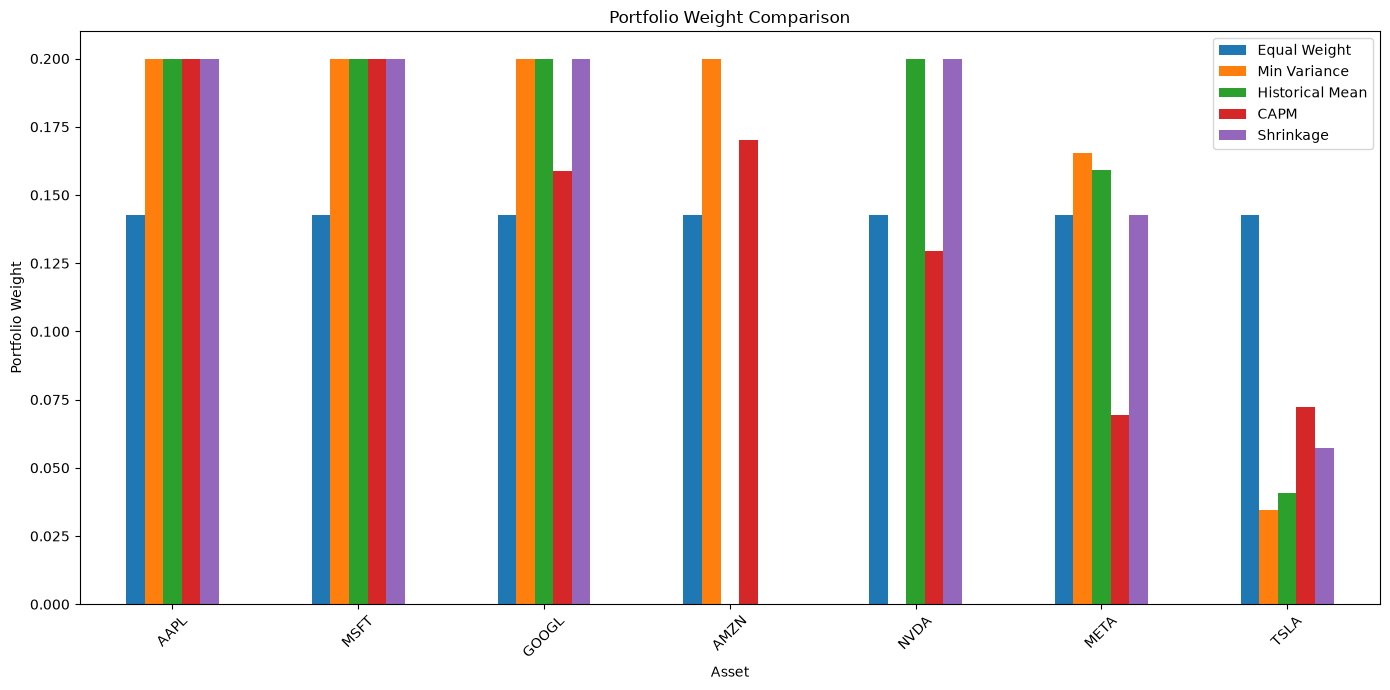

In [41]:
# ==========================================
# Portfolio Weight Comparison
# ==========================================

weight_comparison.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Portfolio Weight Comparison")
plt.ylabel("Portfolio Weight")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()